In [116]:
import math
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [117]:
df = pd.read_csv('../dataset/Walmart.csv')

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('Date').agg({
  'Weekly_Sales': 'sum',
  'Holiday_Flag': 'max',
  'Temperature': 'mean',
  'Fuel_Price': 'mean',
  'CPI': 'mean',
  'Unemployment': 'mean'
}).reset_index()

df.head()

# Graph
#result = seasonal_decompose(df['FEDFUNDS'], model ='multiplicative')
#result.plot()

# data["detrended"] = sm.OLS(data["FEDFUNDS"], sm.add_constant(range(len(data)))).fit().resid
# data["differenced"] = data["FEDFUNDS"].diff()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


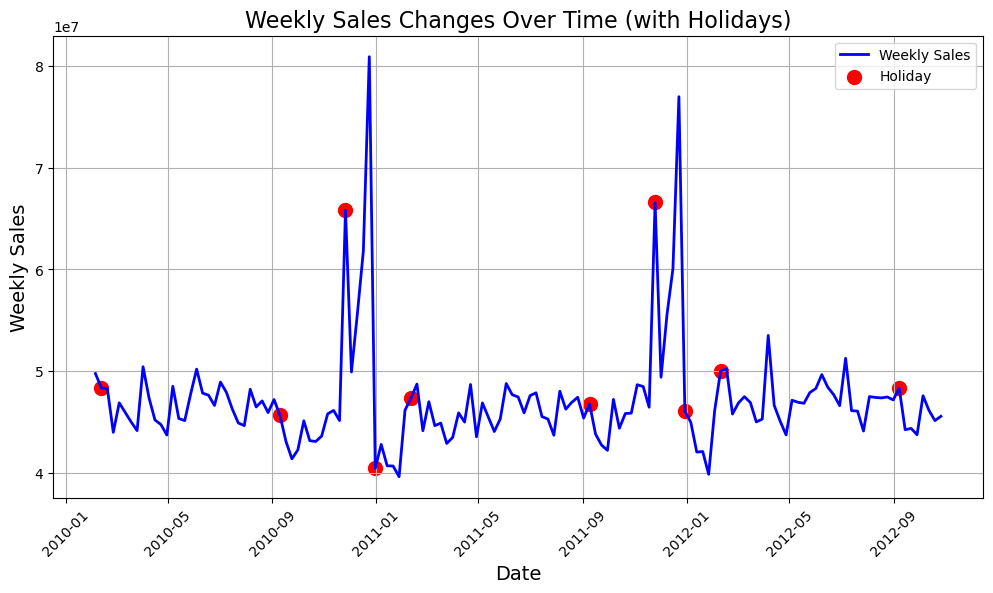

In [118]:
# Plot Weekly Sales over Time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Weekly_Sales'], color='blue', linewidth=2, label='Weekly Sales')

# Highlight Holidays
holiday_dates = df[df['Holiday_Flag'] == 1]  # Filter rows where Holiday_Flag is 1
plt.scatter(holiday_dates['Date'], holiday_dates['Weekly_Sales'], color='red', marker='o', s=100, label='Holiday')

# Add titles and labels
plt.title('Weekly Sales Changes Over Time (with Holidays)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales', fontsize=14)
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show the plot
plt.show()

In [119]:
# ADF Test
result_test = adfuller(df['Weekly_Sales'])

print(f"ADF Statistic: {result_test[0]}")
print(f"P-value: {result_test[1]}")
print(f"Critical Values: {result_test[4]}")

if result_test[1] < 0.05:
  print("Reject H0: Data is stationary")
else:
  print("Fail to reject H0: Data is non-stationary")

ADF Statistic: -5.90829795718633
P-value: 2.6759791589860825e-07
Critical Values: {'1%': np.float64(-3.47864788917503), '5%': np.float64(-2.882721765644168), '10%': np.float64(-2.578065326612056)}
Reject H0: Data is stationary


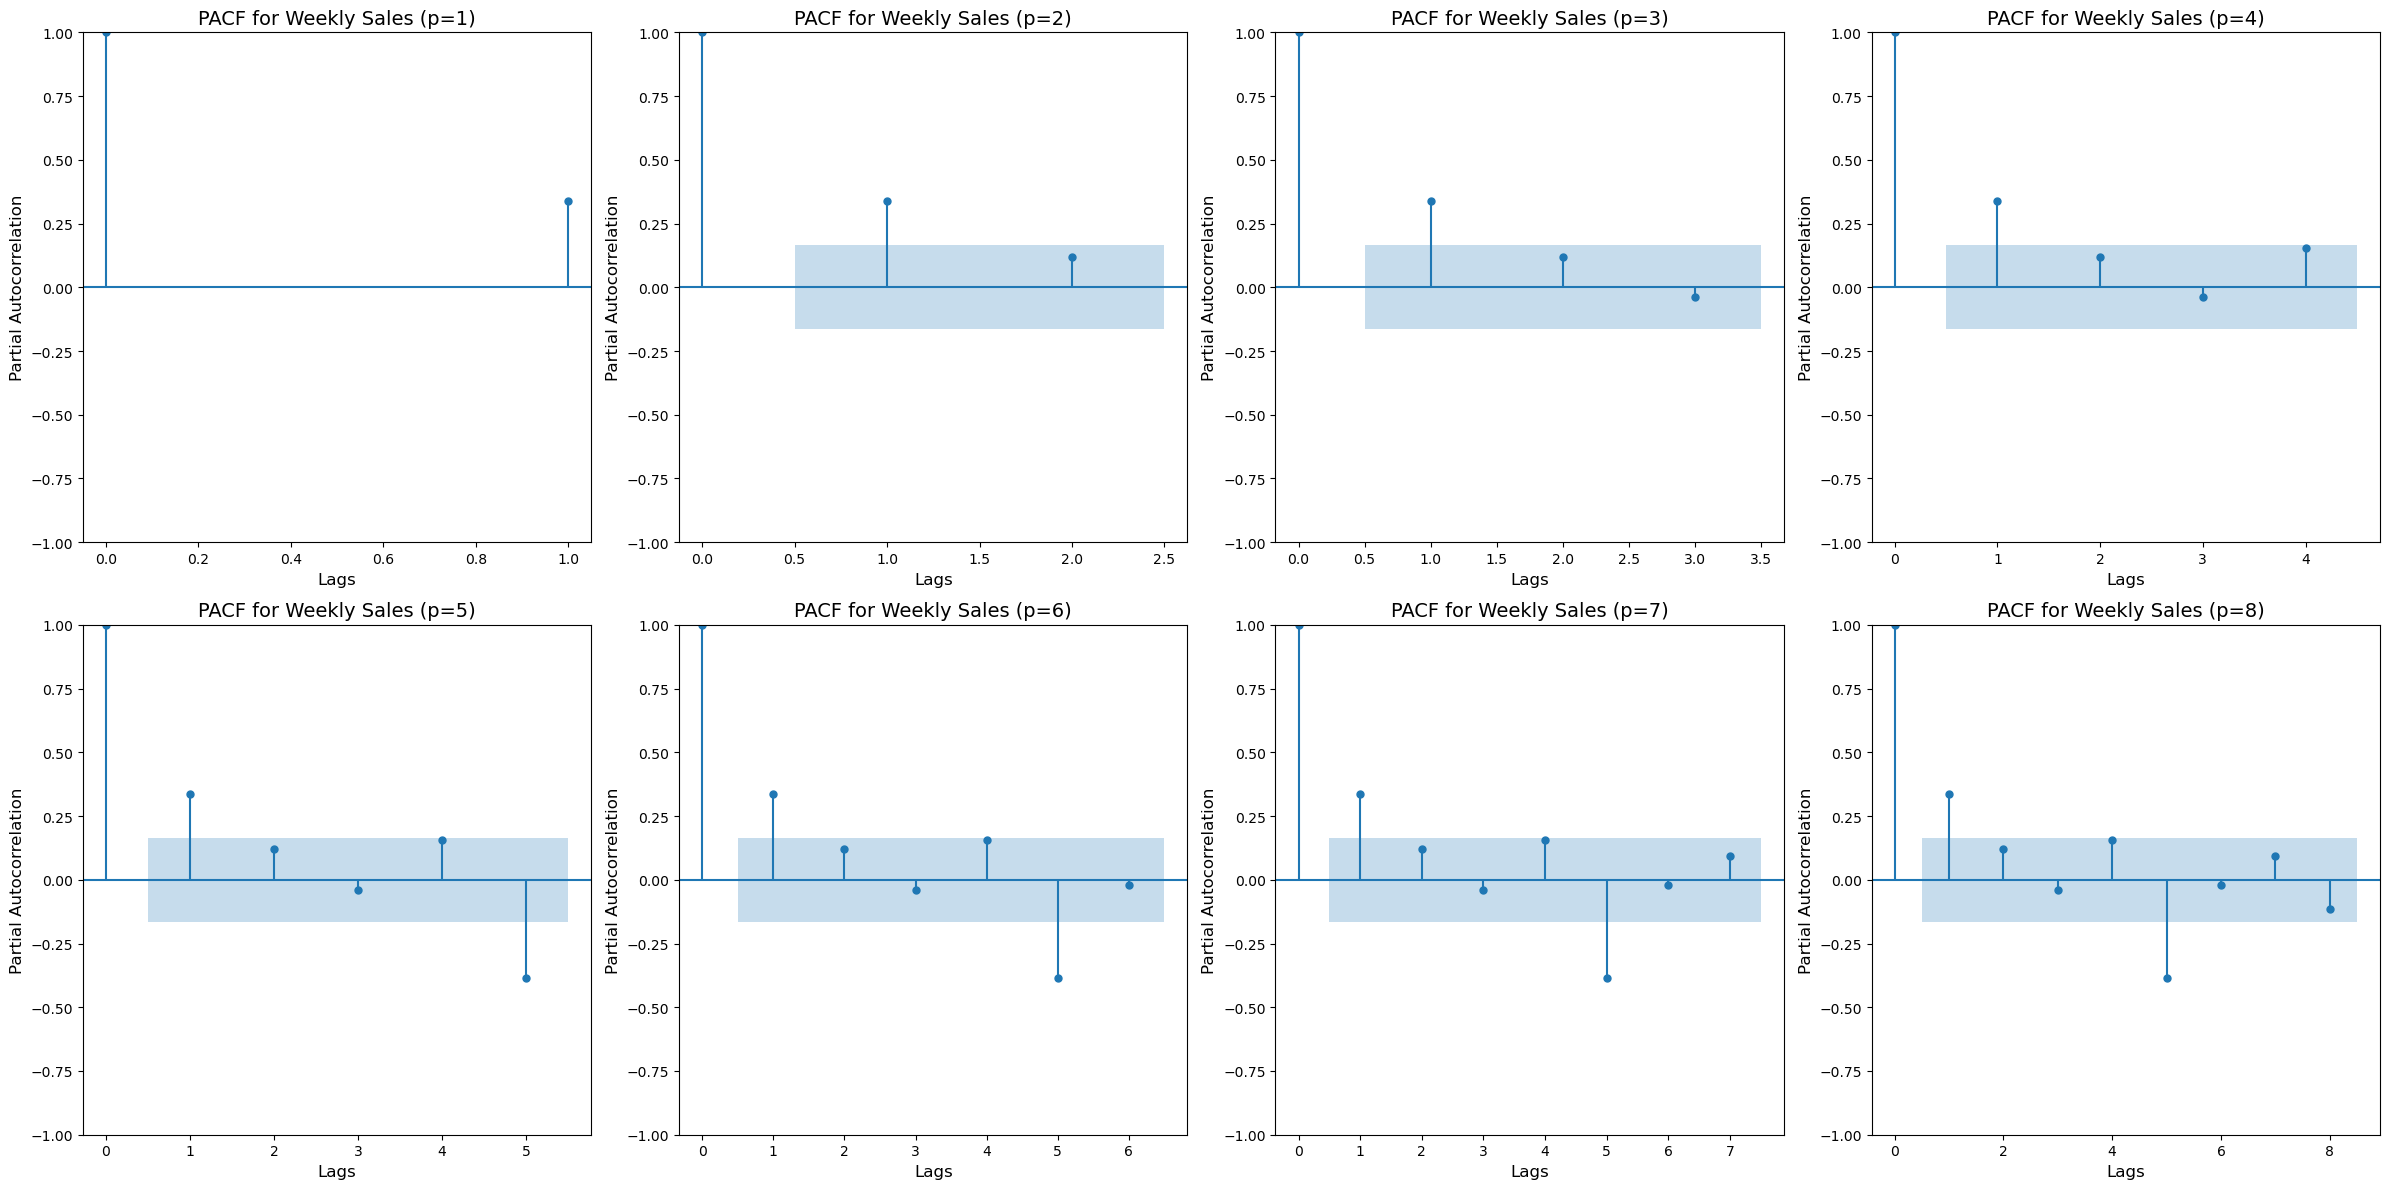

In [120]:
# Plot ACF for 'Weekly_Sales' for different values of p (lags)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # Create subplots for multiple values of p
axes = axes.flatten()

# Different values of p (lags)
p_values = range(1, 9)

for i, p in enumerate(p_values):
  plot_pacf(df['Weekly_Sales'], lags=p, ax=axes[i])
  axes[i].set_title(f'PACF for Weekly Sales (p={p})', fontsize=14)
  axes[i].set_xlabel('Lags', fontsize=12)
  axes[i].set_ylabel('Partial Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()

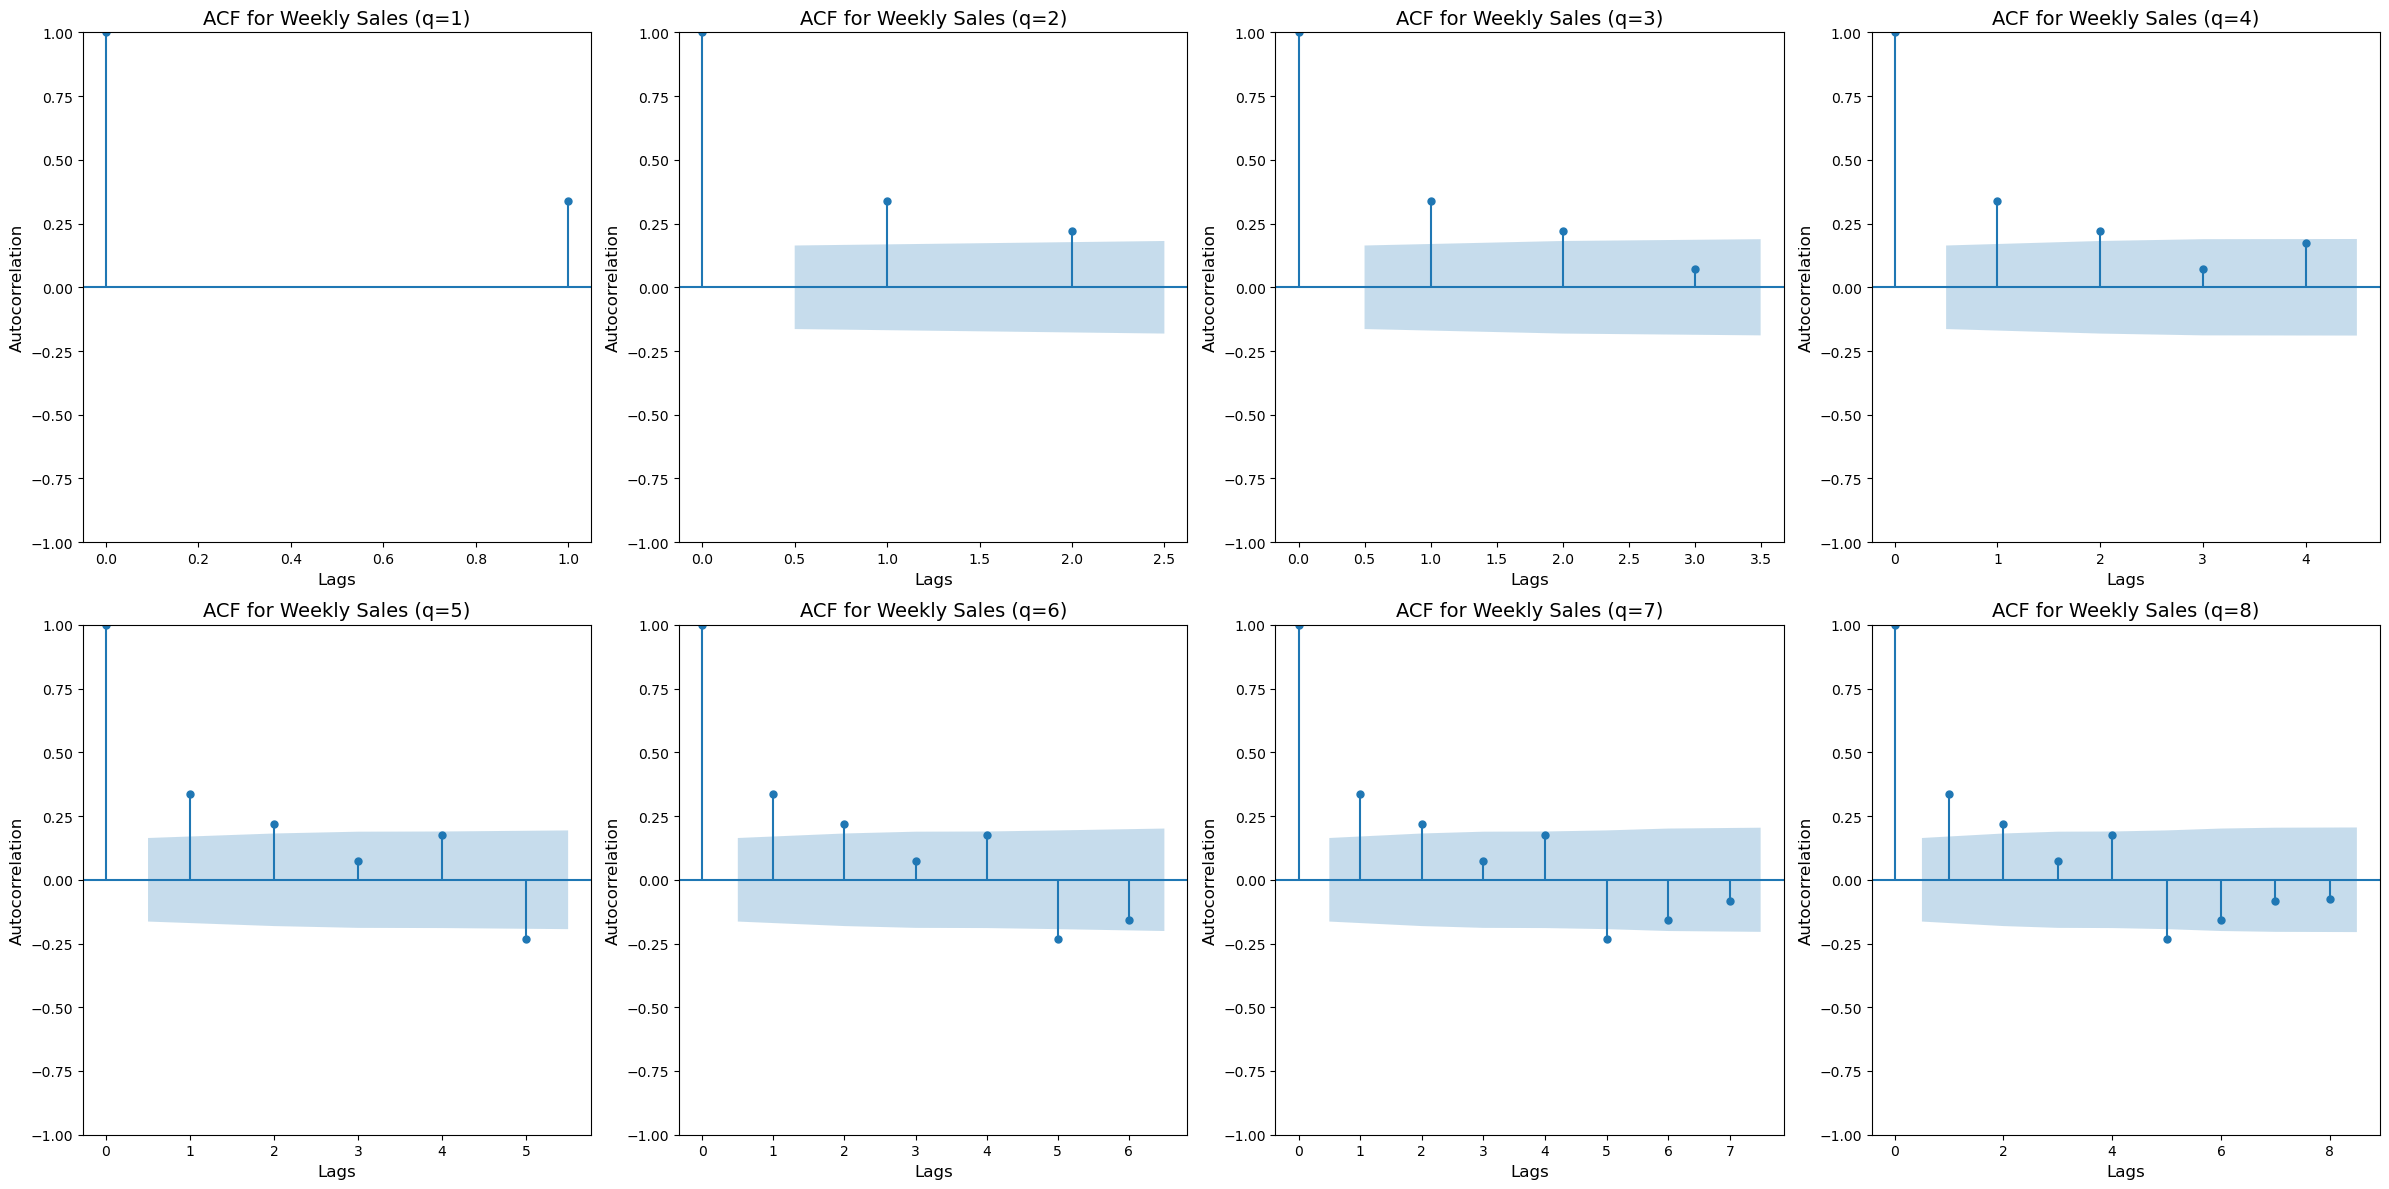

In [121]:
# Plot PACF for 'Weekly_Sales' for different values of q (lags)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # Create subplots for multiple values of p
axes = axes.flatten()

# Different values of q (lags)
q_values = range(1, 9)

for i, q in enumerate(q_values):
  plot_acf(df['Weekly_Sales'], lags=q, ax=axes[i])
  axes[i].set_title(f'ACF for Weekly Sales (q={q})', fontsize=14)
  axes[i].set_xlabel('Lags', fontsize=12)
  axes[i].set_ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()


From our charts, max(p) = max(q) = 5. From our ADF test, d = 0

From previous ADF Test, D = 0

In [122]:
s = 52

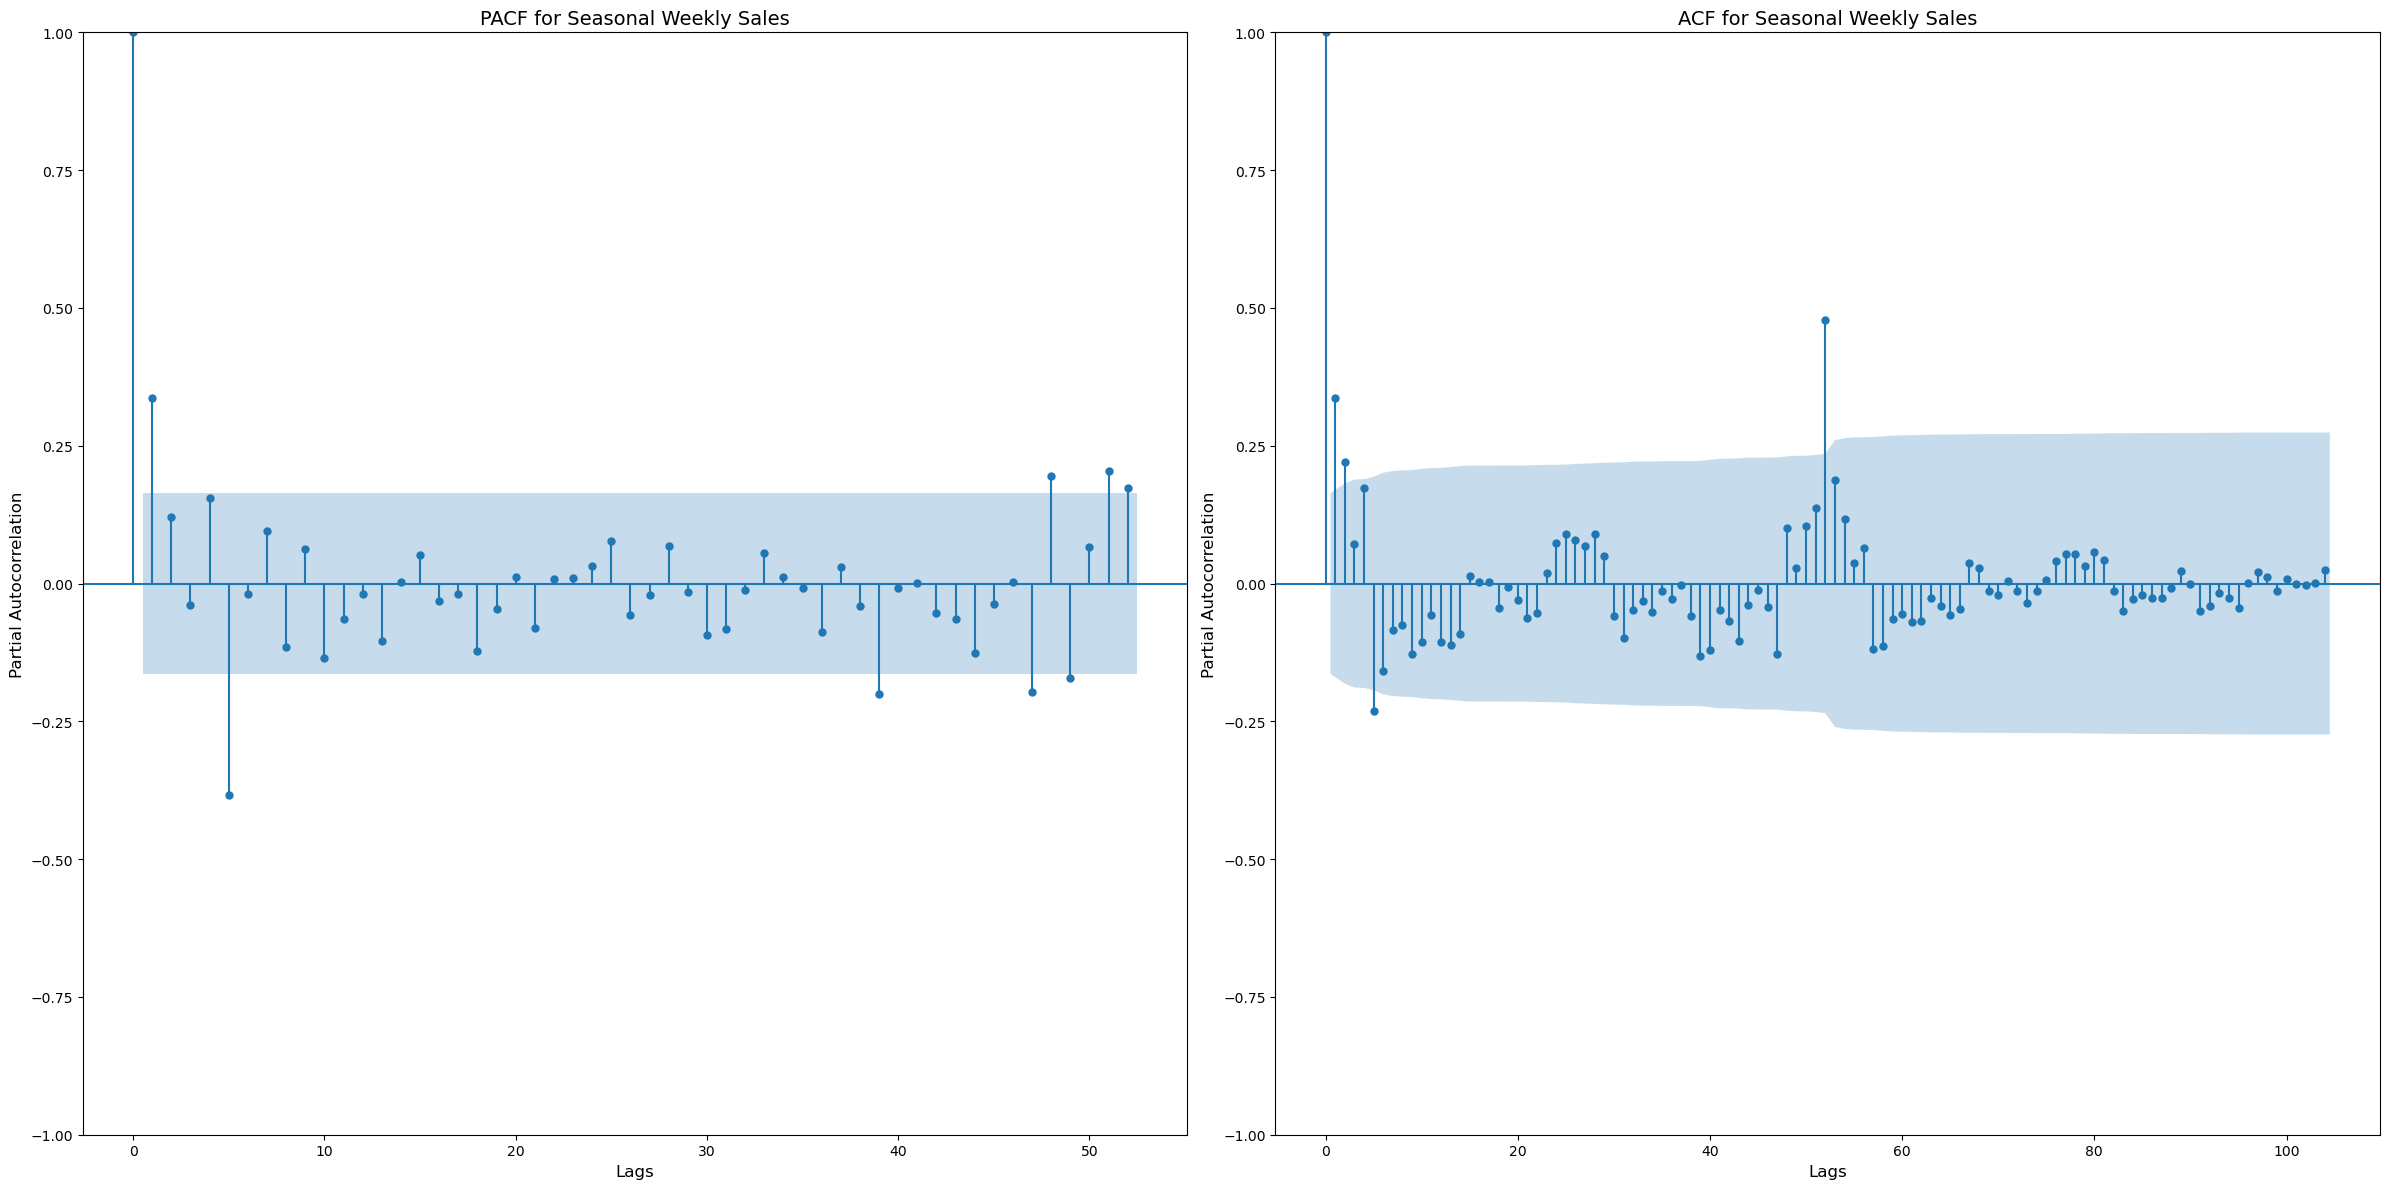

In [123]:
# Plot ACF for 'Weekly_Sales' for different values of P (lags)
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Create subplots for multiple values of p
axes = axes.flatten()

# Different values of p (lags)
plot_pacf(df['Weekly_Sales'], lags=s, ax=axes[0])
axes[0].set_title(f'PACF for Seasonal Weekly Sales', fontsize=14)
axes[0].set_xlabel('Lags', fontsize=12)
axes[0].set_ylabel('Partial Autocorrelation', fontsize=12)

# Different values of q (lags)
plot_acf(df['Weekly_Sales'], lags=s * 2, ax=axes[1])
axes[1].set_title(f'ACF for Seasonal Weekly Sales', fontsize=14)
axes[1].set_xlabel('Lags', fontsize=12)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()

From our analysis, P = Q = 1

In [150]:
# Do grid search
max_p, max_q = 5, 5
max_P, max_Q = 1, 1
d, D = 0, 0

X = df[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
y = df['Weekly_Sales']

curr_AIC = math.inf
best_model = None

def fit_SARIMAX(p, q, P, Q) -> tuple[int, int, MLEModel]:
  model = SARIMAX(y, exog=X, order=(p, d, q), seasonal_order=(P, D, Q, s), enforce_stationarity=False, enforce_invertibility=False)
  fitted = model.fit()
  return p, q, fitted

grid = ((p, q, P, Q) for p in range(max_p + 1) for q in range(max_q + 1) for P in range(max_P + 1) for Q in range(max_Q + 1))

with ThreadPoolExecutor(max_workers=14) as executor:
  results = executor.map(lambda params: fit_SARIMAX(*params), grid)

/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/s

In [152]:
p, q, best_fit = min(results, key=lambda res: res[2].aic)

In [153]:
f'AIC = {best_fit.aic}'

'AIC = 2808.0770820963075'

In [154]:
f'p = {p}, q = {q}'

'p = 1, q = 5'

In [155]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = best_fit.predict(start=0, end=len(y)-1, exog=X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

In [156]:
f'R^2 is {r2}'

'R^2 is 0.3466233762358114'

In [157]:
f'Mean Absolute Error (MAE): {mae}'

'Mean Absolute Error (MAE): 2371607.327911023'

In [158]:
f'Mean Squared Error (MSE): {mse}'

'Mean Squared Error (MSE): 19230254475769.094'

In [159]:
f'Root Mean Squared Error (RMSE): {rmse}'

'Root Mean Squared Error (RMSE): 4385231.40504228'

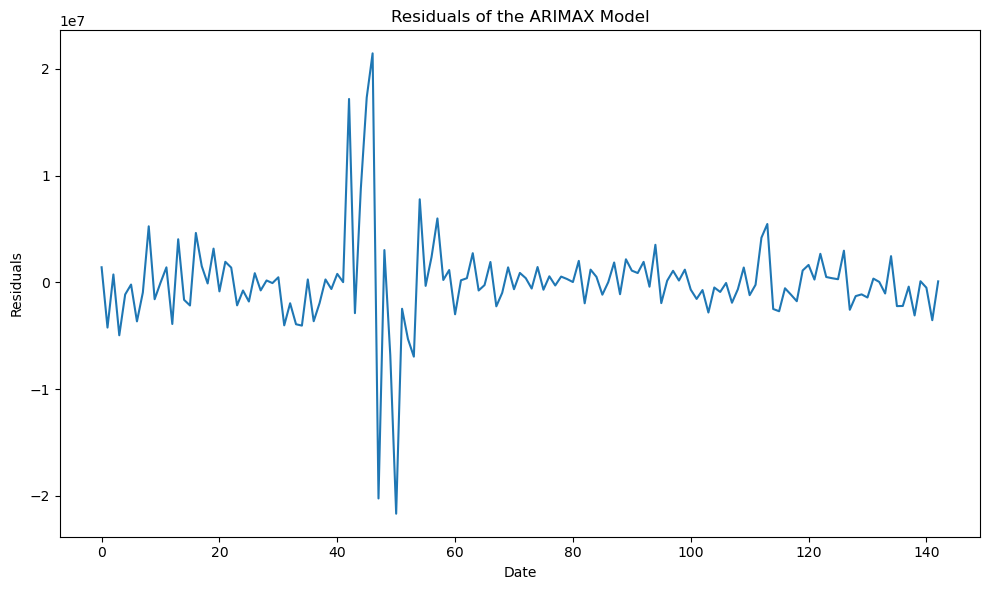

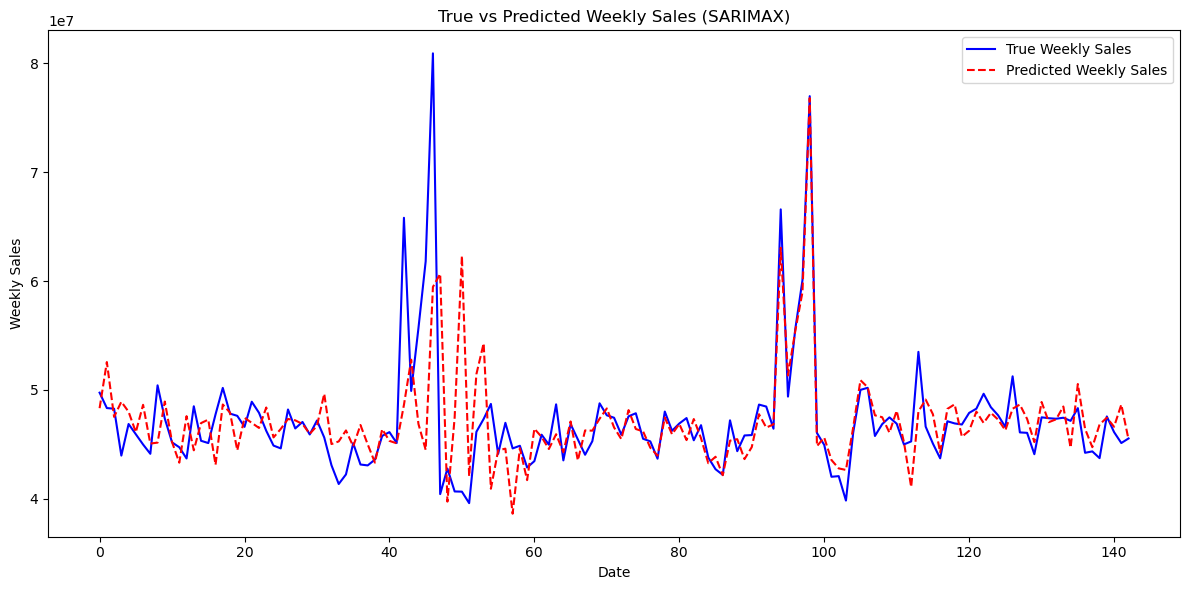

In [161]:
# Plot residuals to check if they resemble white noise
residuals = y - y_pred
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals of the ARIMAX Model")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# Plot predicted vs. true Weekly Sales
plt.figure(figsize=(12, 6))
plt.plot(y, label="True Weekly Sales", color='blue')
plt.plot(y_pred, label="Predicted Weekly Sales", color='red', linestyle='--')
plt.legend()
plt.title("True vs Predicted Weekly Sales (SARIMAX)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

In [162]:
best_fit.save('SARIMAX.pkl')